In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sgd

import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
})

import func

In [2]:
device = "cuda:1"

def align(u,v):
	return np.sum(u*v)/np.sqrt(np.sum(u**2)*np.sum(v**2))

def ortho_mat(k, d):
    A = np.random.randn(d, k)
    Q, _ = np.linalg.qr(A)
    return Q.T

In [3]:
d = 200
gamma = 0.5
alpha = 1
k = int(gamma*d)
n = int(alpha*d**2)  

Delta = 0.01
sig = lambda x: torch.tanh(2*x)

v_np = np.array([1/p for p in range(1, k+1)])


v_np /= np.linalg.norm(v_np)
v0 = torch.tensor(v_np, dtype=torch.float32, device=device)

In [4]:
eta = 0.003 
n_epoch = 10000
n_batch = 3
n_test = 10000

In [5]:
W0 = torch.from_numpy(ortho_mat(k, d).T).float().to(device)
X_train = torch.randn(n, d, device=device)
X_test  = torch.randn(n_test, d, device=device)

with torch.no_grad():
    Y_train = sig(X_train @ W0) @ v0 + torch.randn(n, device=device)*Delta**(.5)
    Y_test  = sig(X_test  @ W0) @ v0 

v_init = torch.full((k,), 0.0, device=device)

widths = [k, 15]
Es_train = []
Es_test = []
Wfs = []
vfs = []
for width in widths:
    v_init = torch.full((width,), width**-.5, device=device)
    E_train, E_test, Wf, vf = sgd.train2(d, v_init[:width], n, sig, n_batch, n_epoch, eta, X_train, Y_train, X_test, Y_test, normalize=True, device=device)
    Es_train.append(E_train)
    Es_test.append(E_test)
    Wfs.append(Wf)
    vfs.append(vf)

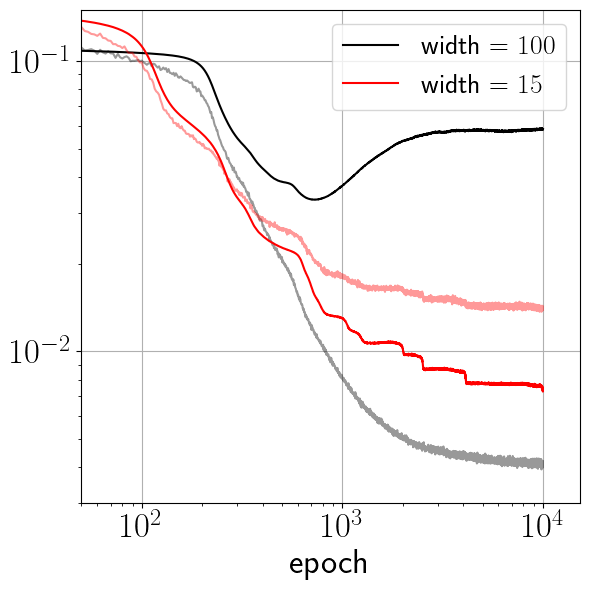

In [6]:
width, height = 6, 6
size = 25
fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)
ax.tick_params(axis='both', labelsize=size)


colors = ['black', 'red']

interval=2
epochs = range(0, n_epoch, interval)

for i in range(len(widths)):
    plt.plot(epochs, Es_train[i][::interval], color=colors[i], alpha=0.4)
    plt.plot(epochs, Es_test[i][::interval], color=colors[i], label=fr'width $={widths[i]}$')

plt.ylim(0.003, 0.15)
plt.legend()
plt.xscale('log')
plt.yscale('log')

plt.xlabel('epoch', fontsize=size)
plt.xlim(50,)
plt.grid()
plt.legend(fontsize = 20)
plt.show()


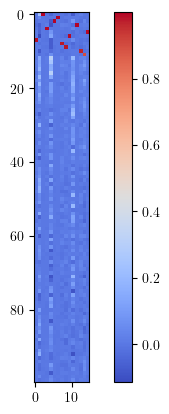

In [9]:

ind = 1
vf = vfs[ind]
Wf = Wfs[ind]

W0_ = np.array(W0.cpu()).T
Q = W0_@np.array(Wf).T
plt.imshow(Q, cmap='coolwarm')
plt.colorbar()
plt.show()
